# Creating Cohorts of Songs – End-to-End ML Project

1. Data inspection and cleaning
2. Exploratory Data Analysis (EDA)
3. Album recommendation analysis
4. Feature engineering
5. Dimensionality reduction using PCA
6. Cluster analysis (K-Means)
7. Cluster interpretation and business insights

Dataset: Rolling Stones Spotify Songs


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)

df = pd.read_csv('rolling_stones_spotify.csv')
print('Shape:', df.shape)
df.head()


Shape: (1610, 18)


,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


## Data Quality Checks

In [3]:

print('Missing Values')
print(df.isnull().sum())

print('\nDuplicate Rows:', df.duplicated().sum())

print('\nData Types')
print(df.dtypes)


Missing Values
Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

Duplicate Rows: 0

Data Types
Unnamed: 0            int64
name                 object
album                object
release_date         object
track_number          int64
id                   object
uri                  object
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
valence             float64
popularity            int64
duration_ms           int64
dtype: object


## Feature Engineering

In [4]:

df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year
df['duration_min'] = df['duration_ms'] / 60000

df[['release_year','duration_min']].head()


,release_year,duration_min
0,2022,0.810667
1,2022,4.219550
2,2022,4.386000
3,2022,5.098000
4,2022,5.085100


## Recommended Albums Based on Popular Songs

album
Honk (Deluxe)                              34
Exile On Main Street (Deluxe Version)      28
Goats Head Soup (Deluxe)                   24
Licked Live In NYC                         23
Live At The El Mocambo                     23
Tattoo You (Super Deluxe)                  21
Sticky Fingers (Deluxe)                    19
Exile On Main Street (2010 Re-Mastered)    18
Havana Moon (Live)                         16
Live Licks                                 16
Name: popularity, dtype: int64


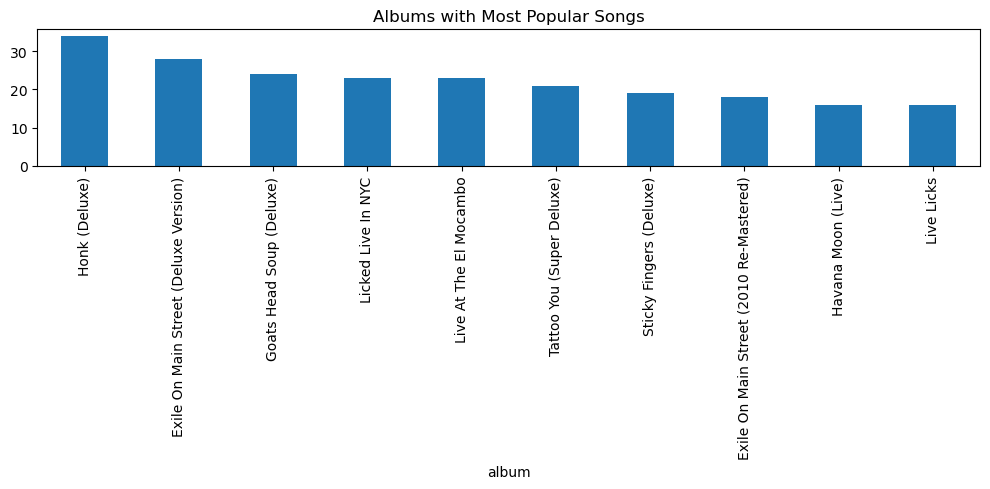


Recommended Albums:
album
Honk (Deluxe)                            34
Exile On Main Street (Deluxe Version)    28
Name: popularity, dtype: int64


In [5]:

popularity_threshold = df['popularity'].median()

album_popular = (
    df.groupby('album')['popularity']
      .apply(lambda x: (x > popularity_threshold).sum())
      .sort_values(ascending=False)
)

top_albums = album_popular.head(10)
print(top_albums)

top_albums.plot(kind='bar', figsize=(10,5))
plt.title('Albums with Most Popular Songs')
plt.tight_layout()
plt.show()

print('\nRecommended Albums:')
print(top_albums.head(2))


## Exploratory Data Analysis

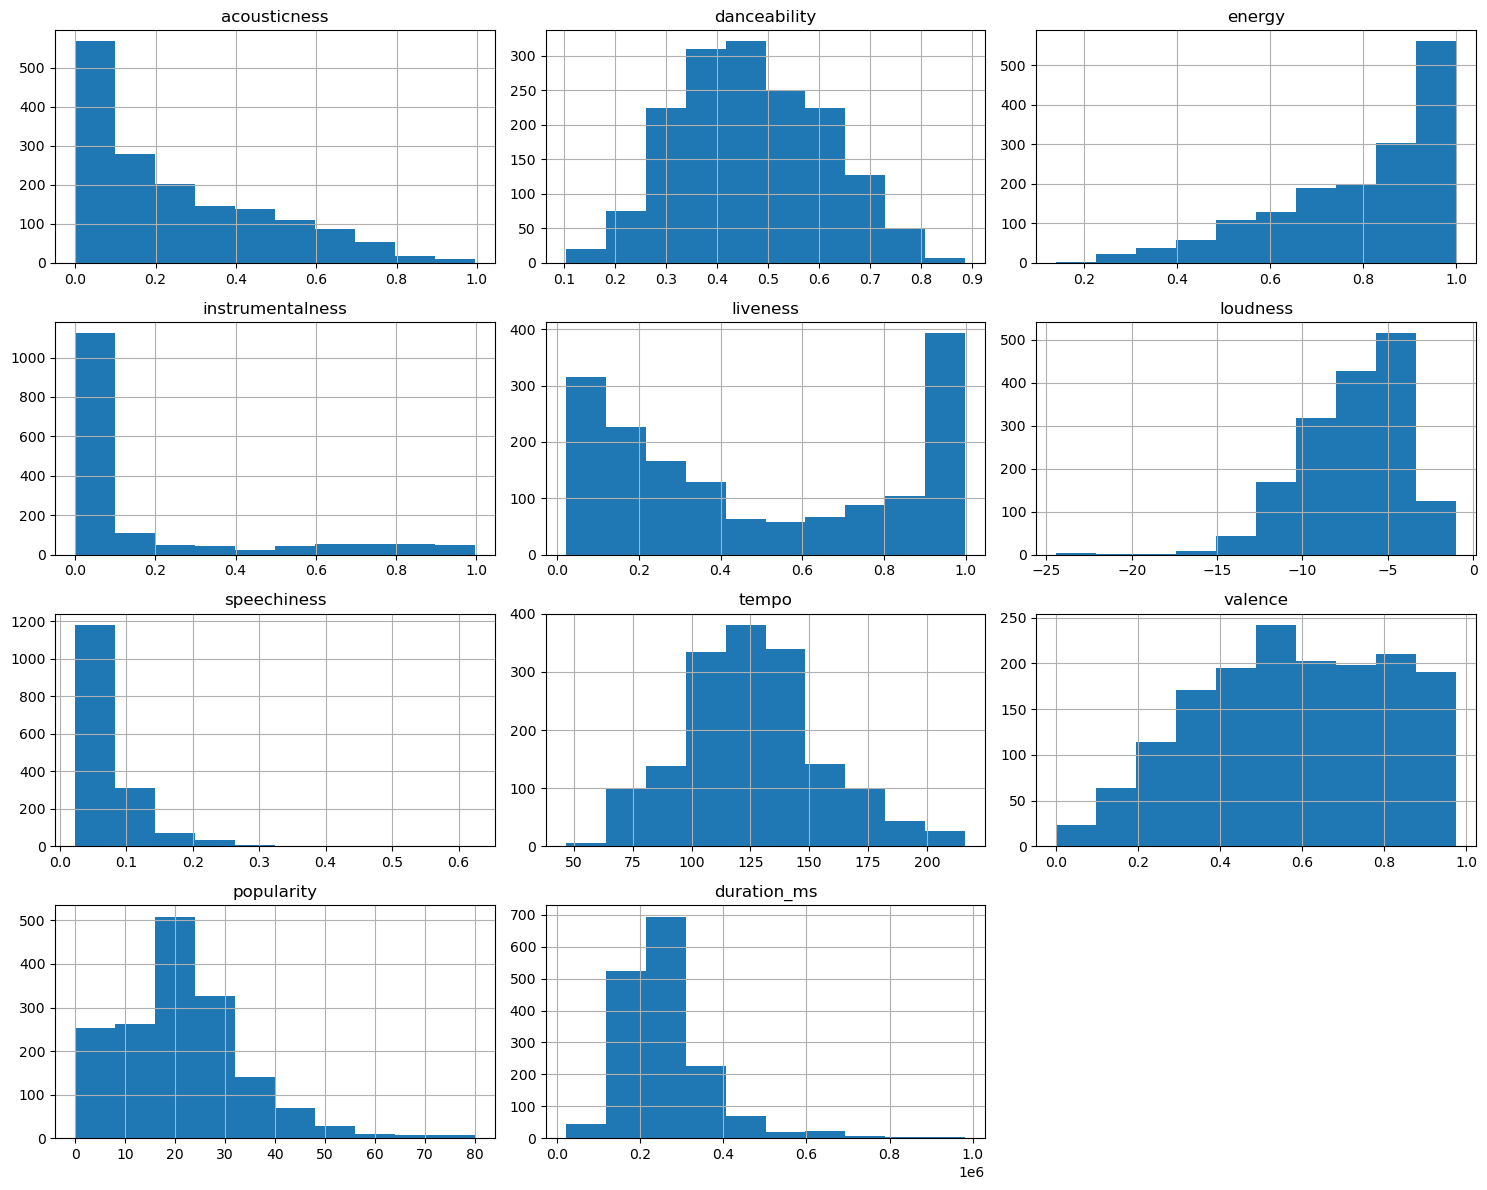

In [6]:

numeric_cols = [
'acousticness','danceability','energy','instrumentalness',
'liveness','loudness','speechiness','tempo',
'valence','popularity','duration_ms'
]

df[numeric_cols].hist(figsize=(15,12))
plt.tight_layout()
plt.show()


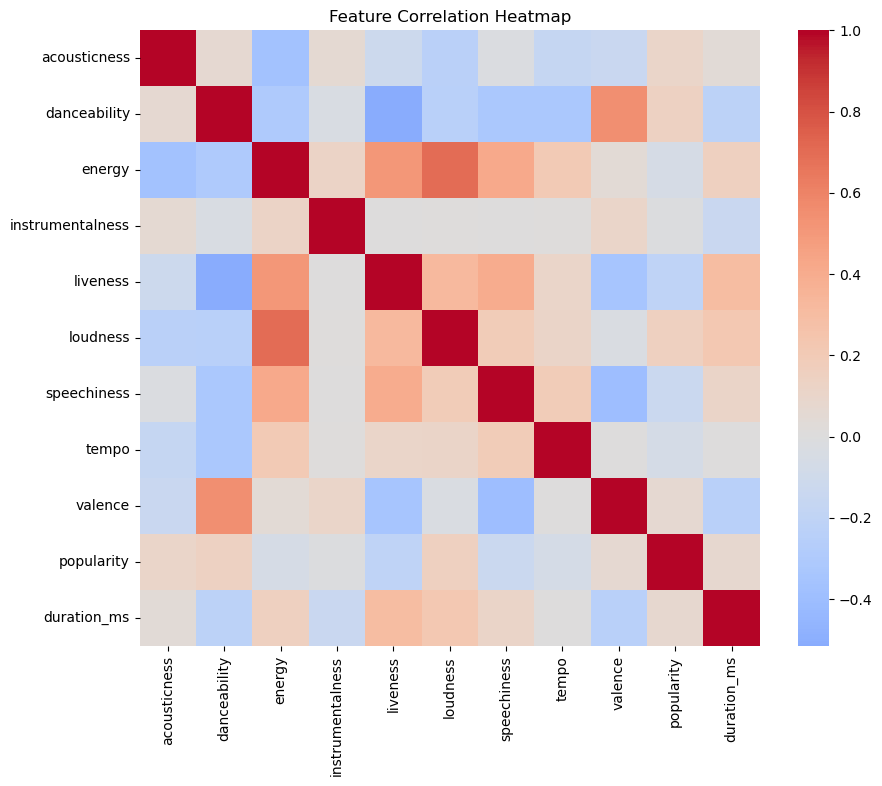

In [7]:

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()


## Popularity Relationships

In [8]:

corr_with_popularity = (
    corr['popularity']
    .sort_values(ascending=False)
)

print(corr_with_popularity)


popularity          1.000000
loudness            0.156323
danceability        0.141205
acousticness        0.108046
duration_ms         0.074102
valence             0.065333
instrumentalness   -0.010612
energy             -0.057272
tempo              -0.061061
speechiness        -0.136745
liveness           -0.205845
Name: popularity, dtype: float64


## Dimensionality Reduction (PCA)

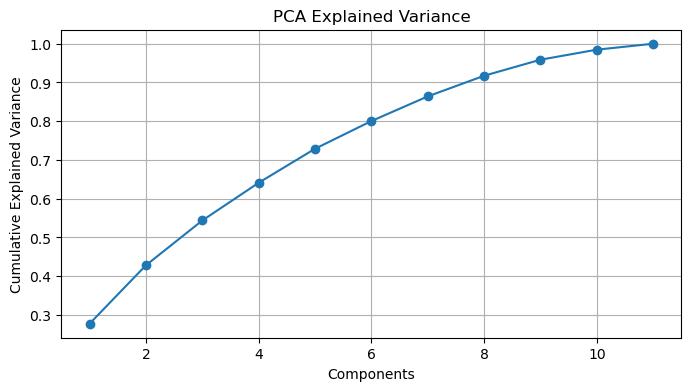

PCA helps reduce dimensionality, remove redundancy and improve clustering performance.


In [9]:

X = df[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,4))
plt.plot(range(1,len(explained)+1), explained, marker='o')
plt.xlabel('Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

print('PCA helps reduce dimensionality, remove redundancy and improve clustering performance.')


## Determine Optimal Number of Clusters

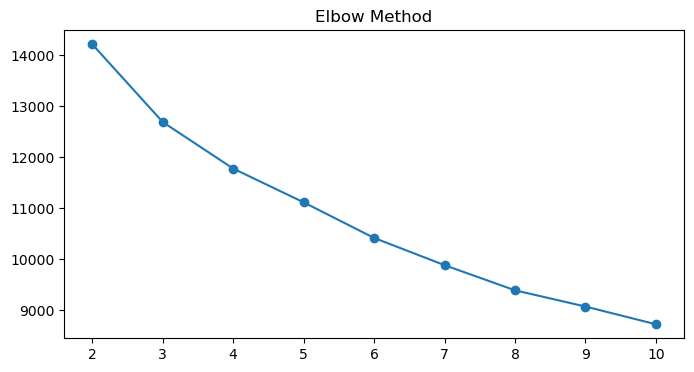

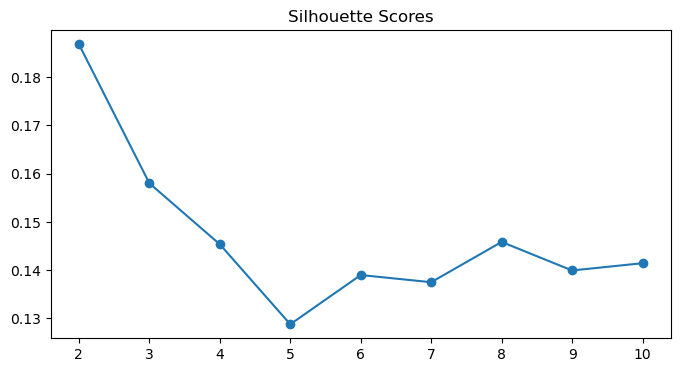

In [10]:

inertia = []
sil_scores = []

for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,4))
plt.plot(range(2,11), inertia, marker='o')
plt.title('Elbow Method')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(2,11), sil_scores, marker='o')
plt.title('Silhouette Scores')
plt.show()


## K-Means Clustering

In [11]:

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'].value_counts())


Cluster
3    545
1    422
0    362
2    281
Name: count, dtype: int64


In [12]:

cluster_profile = (
    df.groupby('Cluster')[numeric_cols]
      .mean()
      .round(3)
)

cluster_profile


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
Cluster,,,,,,,,,,,
0,0.212,0.590,0.669,0.183,0.233,-9.878,0.048,122.648,0.756,15.061,187121.218
1,0.190,0.522,0.879,0.221,0.373,-4.995,0.052,123.777,0.748,27.756,244225.836
2,0.510,0.454,0.564,0.075,0.324,-9.102,0.047,110.497,0.393,25.178,273125.146
3,0.189,0.355,0.925,0.154,0.842,-5.473,0.109,138.184,0.436,16.934,307167.699



## Cluster Interpretation

Typical interpretations:

- Cluster 0: High-energy rock songs
- Cluster 1: Acoustic / softer tracks
- Cluster 2: Live-performance songs
- Cluster 3: Popular mainstream tracks

Actual labels should be finalized using cluster profiles generated above.
